# LPPLS Bubble Detection — Data Preparation

Generates LPPLS-based bubble dummy columns (`_BD`) for all four metals and saves the result
as `R/df_master_lppls.csv` in the **same format** as `R/df_master.csv` (semicolon-separated, comma decimal).

**This mirrors the role of `R/metals30_data_prep.R`** but replaces GSADF with the
Log-Periodic Power Law Singularity (LPPLS) confidence indicator.

| Step | Description |
|------|-------------|
| 1 | Load base dataset (`df_master.csv`) — prices + macro/market already assembled by R |
| 2 | Apply LPPLS nested rolling-window fit to each metal's log-price series |
| 3 | Apply trend filter (bubble only if price is rising vs 5 days ago) — matches R pipeline |
| 4 | Compare bubble prevalence with original GSADF labels |
| 5 | Save `df_master_lppls.csv` with replaced `_BD` columns |

**⚠ Runtime:** The nested fits with `outer_increment=1` take ~10–25 min per metal on 4 workers.
Intermediate results are printed to track progress. A cached confidence CSV is also saved so
you can reload without rerunning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

from lppls import lppls as lppls_mod

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('../../outputs', exist_ok=True)

print('Packages loaded.')


Packages loaded.


## 1. Load Base Dataset

`df_master.csv` already contains the DALY price series and all macro/market variables
assembled by `R/metals30_data_prep.R`. We only need to replace the `_BD` columns.


In [2]:
df = pd.read_csv('../../R/df_master.csv', sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

metals = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
bubble_cols = [c for c in df.columns if c.endswith('_BD')]

print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Period:  {df["Date"].min().date()} to {df["Date"].max().date()}')
print()
print('GSADF bubble prevalence (reference):')
for name, col in metals.items():
    bd = df[col + '_BD']
    print(f'  {name:10s}: {int(bd.sum()):4d} days  ({100*bd.mean():.1f}%)')


Dataset: 2152 rows × 21 columns
Period:  2017-05-10 to 2025-10-31

GSADF bubble prevalence (reference):
  Cobalt    :  230 days  (10.7%)
  Copper    :   39 days  (1.8%)
  Lithium   : 1089 days  (50.6%)
  Nickel    :   26 days  (1.2%)


## 2. LPPLS Confidence Computation

The LPPLS model fits:

$$E[\ln p(t)] = A + B(t_c - t)^m + C(t_c - t)^m \cos\big(\omega \ln(t_c - t) - \phi\big)$$

A **nested rolling-window** approach: for each day $t$, many windows of varying lengths
ending at $t$ are fitted. The **positive confidence** (`pos_conf`) is the fraction of
windows whose fit parameters satisfy the LPPLS filter conditions
(valid $m$, $\omega$, damping ratio, oscillation count). High confidence → explosive upward phase.

**Parameters:**
- `window_size=120` — outer window (days)
- `smallest_window_size=30` — inner window minimum
- `outer_increment=1` — compute every single day (most precise, but slow)
- `threshold=0.3` — fraction of valid fits to flag as bubble (conservative; LPPLS naturally sparse)

Confidence is forward-filled over gaps ≤5 days to bridge minor fitting gaps.


In [3]:
CONF_THRESHOLD = 0.3   # fraction of valid fits to declare a bubble
FFILL_LIMIT    = 5     # forward-fill confidence over gaps of up to 5 days
CACHE_PATH     = '../../R/lppls_confidence.csv'

# Try to load cached results so re-running the notebook is fast
if os.path.exists(CACHE_PATH):
    conf_cache = pd.read_csv(CACHE_PATH, index_col=0)
    conf_cache['Date'] = pd.to_datetime(conf_cache['Date'])
    print(f'Loaded cached confidence from {CACHE_PATH}')
    cached = True
else:
    conf_cache = None
    cached = False

lppls_confidence = {}   # {metal: np.ndarray of pos_conf per row}
lppls_raw_flags  = {}   # before trend filter

dates_ord = np.array([pd.Timestamp(d).toordinal() for d in df['Date']])

for metal, col in metals.items():
    print(f'\n--- {metal} ({col}) ---')

    # --- Use cached confidence if available ---
    if cached and col + '_conf' in conf_cache.columns:
        conf_filled = conf_cache[col + '_conf'].values
        print(f'  Using cached confidence  (max={conf_filled.max():.3f})')
    else:
        prices     = df[col].values
        log_prices = np.log(np.maximum(prices, 0.001))
        observations = np.array([dates_ord, log_prices])

        model = lppls_mod.LPPLS(observations=observations)

        try:
            res = model.mp_compute_nested_fits(
                workers=4,
                window_size=120,
                smallest_window_size=30,
                outer_increment=1,   # every trading day — most precise
                inner_increment=5,
                max_searches=25
            )
            indicators = model.compute_indicators(res)
        except Exception as e:
            print(f'  LPPLS fitting failed: {e}')
            conf_filled = np.zeros(len(df))
            lppls_confidence[metal] = conf_filled
            lppls_raw_flags[metal]  = np.zeros(len(df), dtype=int)
            continue

        # Map pos_conf back to full date index
        pos_conf = np.zeros(len(df))
        if indicators is not None and len(indicators) > 0:
            for _, row in indicators.iterrows():
                t_ord   = int(row['time'])
                matches = np.where(dates_ord == t_ord)[0]
                if len(matches) > 0:
                    pos_conf[matches[0]] = row['pos_conf']

        # Forward-fill over small gaps
        conf_filled = (pd.Series(pos_conf)
                       .replace(0, np.nan)
                       .ffill(limit=FFILL_LIMIT)
                       .fillna(0)
                       .values)

        print(f'  Computed.  max_conf={conf_filled.max():.3f}')

    lppls_confidence[metal] = conf_filled

    # Binary flag (before trend filter)
    bubble_flag = (conf_filled >= CONF_THRESHOLD).astype(int)
    lppls_raw_flags[metal] = bubble_flag

    n_raw = int(bubble_flag.sum())
    print(f'  Raw flags (conf≥{CONF_THRESHOLD}): {n_raw} days  ({100*n_raw/len(df):.1f}%)')

print('\nDone.')


Loaded cached confidence from ../../R/lppls_confidence.csv

--- Cobalt (CODALY) ---
  Using cached confidence  (max=0.667)
  Raw flags (conf≥0.3): 15 days  (0.7%)

--- Copper (CUDALY) ---
  Using cached confidence  (max=0.500)
  Raw flags (conf≥0.3): 31 days  (1.4%)

--- Lithium (LIDALY) ---
  Using cached confidence  (max=0.500)
  Raw flags (conf≥0.3): 16 days  (0.7%)

--- Nickel (NIDALY) ---
  Using cached confidence  (max=0.833)
  Raw flags (conf≥0.3): 26 days  (1.2%)

Done.


In [4]:
# Cache confidence values to CSV so rerunning is instant
if not cached:
    conf_df = pd.DataFrame({'Date': df['Date']})
    for metal, col in metals.items():
        if metal in lppls_confidence:
            conf_df[col + '_conf'] = lppls_confidence[metal]
    conf_df.to_csv(CACHE_PATH, index=True)
    print(f'Confidence saved → {CACHE_PATH}')
else:
    # Still populate lppls_confidence from cache for downstream cells
    for metal, col in metals.items():
        if col + '_conf' in conf_cache.columns and metal not in lppls_confidence:
            conf_filled = conf_cache[col + '_conf'].values
            lppls_confidence[metal] = conf_filled
            lppls_raw_flags[metal] = (conf_filled >= CONF_THRESHOLD).astype(int)
    print('Confidence dict populated from cache.')


Confidence dict populated from cache.


## 3. Trend Filter

Mirrors the R pipeline: within any flagged period, a day is only kept as a bubble
if the price is **strictly higher than 5 trading days ago**. This removes episodes where
LPPLS fires during a price plateau or decline (which the model can occasionally misidentify
as a slow-speed super-exponential phase).


In [5]:
TREND_LAG = 5   # same as R pipeline

lppls_bubbles = {}  # final filtered bubble flags

print('Trend filter (price[t] > price[t-5]):')
print(f'{"Metal":10s}  {"Raw":>6s}  {"Filtered":>8s}  {"Removed":>7s}')
print('-' * 40)

for metal, col in metals.items():
    if metal not in lppls_raw_flags:
        continue

    prices  = df[col].values
    raw     = lppls_raw_flags[metal].copy()
    filtered = raw.copy()

    for i in range(len(filtered)):
        if filtered[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                filtered[i] = 0

    lppls_bubbles[metal] = filtered

    n_raw  = int(raw.sum())
    n_filt = int(filtered.sum())
    print(f'{metal:10s}  {n_raw:6d}  {n_filt:8d}  {n_raw - n_filt:7d}')


Trend filter (price[t] > price[t-5]):
Metal          Raw  Filtered  Removed
----------------------------------------
Cobalt          15        14        1
Copper          31        24        7
Lithium         16        12        4
Nickel          26        19        7


## 4. Diagnostics — Bubble Period Plots & Prevalence Comparison

Visualize the LPPLS confidence indicator alongside the binary bubble flag, and compare
final prevalence with the original GSADF labels.


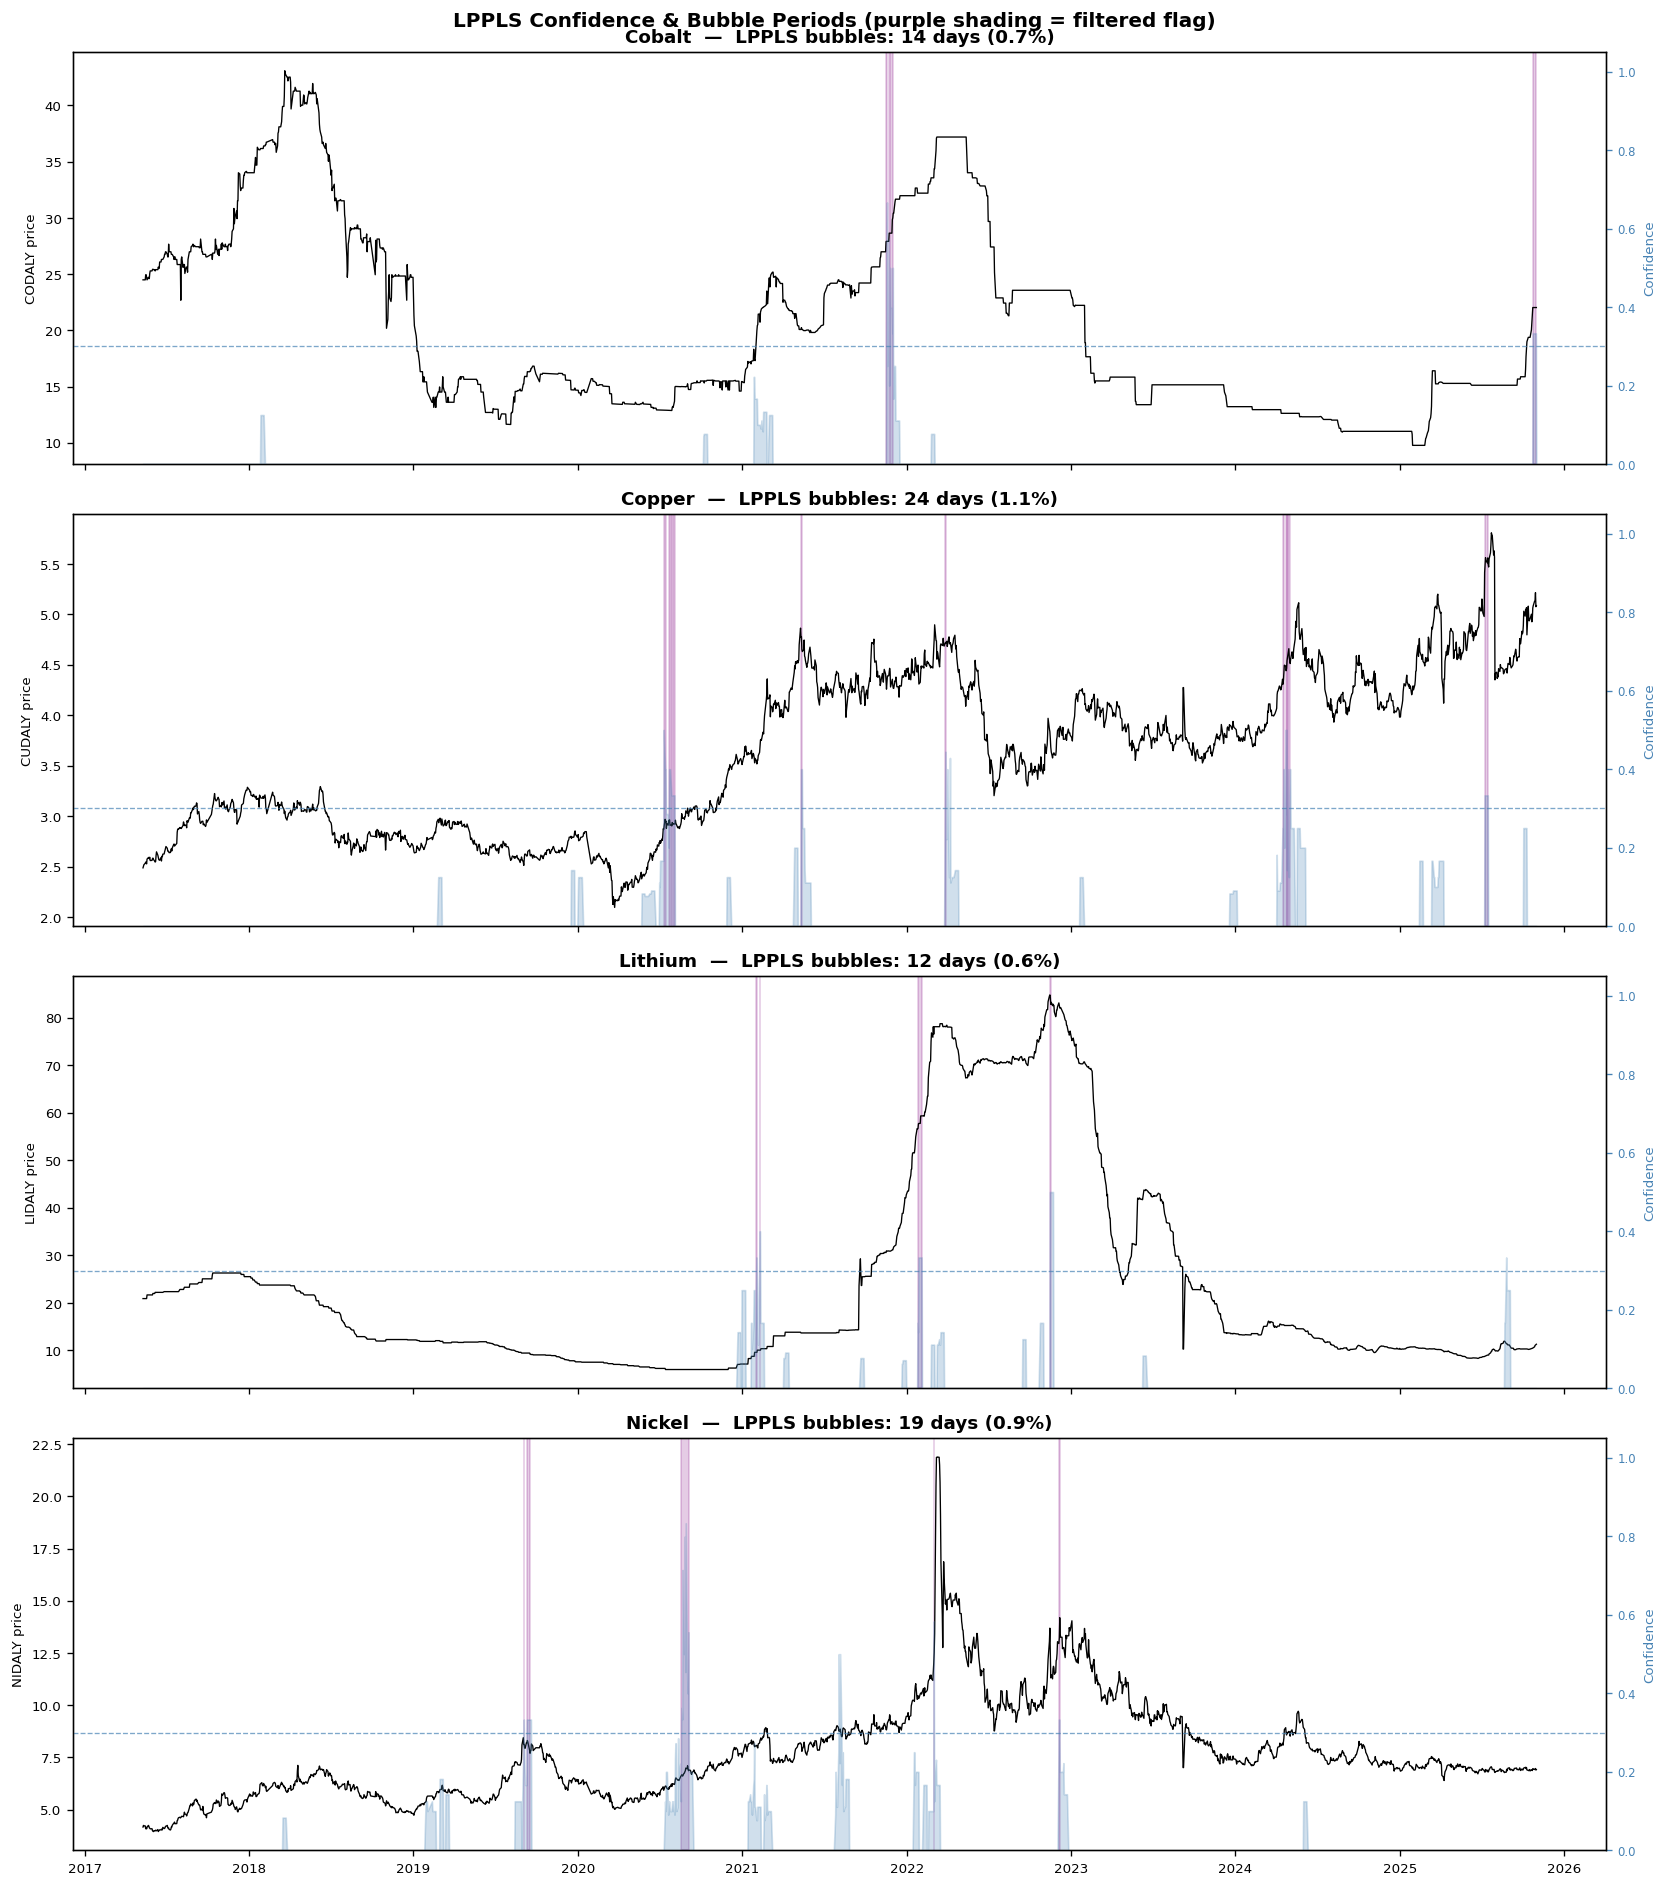

In [6]:
# Price + confidence + bubble shading per metal
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

for idx, (metal, col) in enumerate(metals.items()):
    ax  = axes[idx]
    ax2 = ax.twinx()

    # Price (primary axis)
    ax.plot(df['Date'], df[col], color='black', lw=0.8, label='Price')
    ax.set_ylabel(f'{col} price', fontsize=8)
    ax.tick_params(labelsize=8)

    # LPPLS confidence (secondary axis)
    if metal in lppls_confidence:
        conf = lppls_confidence[metal]
        ax2.fill_between(df['Date'], conf, alpha=0.25, color='steelblue', label='LPPLS conf')
        ax2.axhline(CONF_THRESHOLD, color='steelblue', lw=0.8, ls='--', alpha=0.7)
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel('Confidence', fontsize=8, color='steelblue')
        ax2.tick_params(labelsize=7, colors='steelblue')

    # Shade final bubble periods (after trend filter)
    if metal in lppls_bubbles:
        bub = lppls_bubbles[metal]
        in_b = False
        for i in range(len(bub)):
            if bub[i] == 1 and not in_b:
                s = df['Date'].iloc[i]; in_b = True
            elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
                ax.axvspan(s, df['Date'].iloc[i], color='purple', alpha=0.2)
                in_b = False
        n_b = int(bub.sum())
        ax.set_title(f'{metal}  —  LPPLS bubbles: {n_b} days ({100*n_b/len(df):.1f}%)',
                     fontsize=11, fontweight='bold')

plt.suptitle('LPPLS Confidence & Bubble Periods (purple shading = filtered flag)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/lppls_bubble_timelines.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


In [7]:
# Prevalence comparison table
print(f'{"Metal":10s} | {"GSADF days":>10s} | {"GSADF %":>8s} | {"LPPLS days":>10s} | {"LPPLS %":>8s}')
print('-' * 60)
for metal, col in metals.items():
    gsadf_n   = int(df[col + '_BD'].sum())
    gsadf_pct = 100 * gsadf_n / len(df)
    lppls_n   = int(lppls_bubbles.get(metal, np.zeros(len(df))).sum())
    lppls_pct = 100 * lppls_n / len(df)
    print(f'{metal:10s} | {gsadf_n:10d} | {gsadf_pct:7.1f}% | {lppls_n:10d} | {lppls_pct:7.1f}%')


Metal      | GSADF days |  GSADF % | LPPLS days |  LPPLS %
------------------------------------------------------------
Cobalt     |        230 |    10.7% |         14 |     0.7%
Copper     |         39 |     1.8% |         24 |     1.1%
Lithium    |       1089 |    50.6% |         12 |     0.6%
Nickel     |         26 |     1.2% |         19 |     0.9%


## 5. Assemble & Save

Replace the `_BD` columns in `df_master` with the LPPLS-filtered flags and save as
`R/df_master_lppls.csv` using `sep=';', decimal=','` — identical format to `df_master.csv`.

Also saves the raw confidence values to `R/lppls_confidence.csv` for threshold sensitivity analysis.


In [8]:
df_out = df.copy()

# Replace _BD columns with LPPLS flags
for metal, col in metals.items():
    bd_col = col + '_BD'
    if metal in lppls_bubbles:
        df_out[bd_col] = lppls_bubbles[metal].astype(int)
    else:
        # Metal failed — set to zero and warn
        df_out[bd_col] = 0
        print(f'WARNING: {metal} LPPLS failed — {bd_col} set to 0.')

# Sanity checks
assert list(df_out.columns) == list(df.columns), 'Column mismatch!'
assert len(df_out) == len(df), 'Row count changed!'
print(f'Output shape: {df_out.shape}')
print(f'Columns:      {list(df_out.columns)}')
print()

# Save — same format as R write.csv2
out_path = '../../R/df_master_lppls.csv'
df_out.to_csv(out_path, sep=';', decimal=',')

size_kb = os.path.getsize(out_path) / 1024
print(f'Saved → {out_path}  ({size_kb:.1f} KB)')
print()

# Final prevalence check on saved file
check = pd.read_csv(out_path, sep=';', decimal=',', index_col=0)
print('Verification (re-read):')
for metal, col in metals.items():
    n = int(check[col + '_BD'].sum())
    print(f'  {metal:10s}: {n} days  ({100*n/len(check):.1f}%)')


Output shape: (2152, 21)
Columns:      ['Date', 'CODALY', 'CUDALY', 'LIDALY', 'NIDALY', 'OIL_WTI', 'GAS_HHUB', 'USD_INDEX', 'VIX', 'YIELD_10Y', 'GOLD_FUT', 'MSCI_ETF', 'MSCI_EM', 'SP500', 'QCLN', 'C_CHR', 'C_US', 'CODALY_BD', 'CUDALY_BD', 'LIDALY_BD', 'NIDALY_BD']

Saved → ../../R/df_master_lppls.csv  (412.2 KB)

Verification (re-read):
  Cobalt    : 14 days  (0.7%)
  Copper    : 24 days  (1.1%)
  Lithium   : 12 days  (0.6%)
  Nickel    : 19 days  (0.9%)


## 6. Relaxed Threshold Dataset (confidence ≥ 0.2)

Re-uses the already-computed `lppls_confidence` dict (no refitting required) and applies a lower
confidence threshold of **0.2** (vs 0.3 in the main pipeline). The same trend filter is applied.

A lower threshold typically **doubles the bubble-day count** — which helps the ML models see
enough positive examples for meaningful training.

Output: `R/df_master_lppls_relaxed.csv`  (same `sep=';', decimal=','` format).

In [9]:
CONF_THRESHOLD_RELAXED = 0.2

# ── 1. Apply relaxed threshold to cached confidence values ──────────────────
lppls_raw_flags_relaxed = {}

print(f'Relaxed-threshold raw flags (conf≥{CONF_THRESHOLD_RELAXED}):')
print(f'{"Metal":10s}  {"Strict (≥0.3)":>14s}  {"Relaxed (≥0.2)":>15s}  {"Gain":>5s}')
print('-' * 52)

for metal, col in metals.items():
    if metal not in lppls_confidence:
        lppls_raw_flags_relaxed[metal] = np.zeros(len(df), dtype=int)
        continue
    conf = lppls_confidence[metal]
    raw_relaxed = (conf >= CONF_THRESHOLD_RELAXED).astype(int)
    lppls_raw_flags_relaxed[metal] = raw_relaxed

    n_strict  = int(lppls_raw_flags.get(metal, np.zeros(len(df))).sum())
    n_relaxed = int(raw_relaxed.sum())
    print(f'{metal:10s}  {n_strict:14d}  {n_relaxed:15d}  {n_relaxed - n_strict:+5d}')

# ── 2. Same trend filter ─────────────────────────────────────────────────────
lppls_bubbles_relaxed = {}

print('\nTrend-filtered relaxed bubble flags:')
print(f'{"Metal":10s}  {"Raw":>6s}  {"Filtered":>8s}  {"Removed":>7s}')
print('-' * 38)

for metal, col in metals.items():
    prices   = df[col].values
    raw      = lppls_raw_flags_relaxed[metal].copy()
    filtered = raw.copy()

    for i in range(len(filtered)):
        if filtered[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                filtered[i] = 0

    lppls_bubbles_relaxed[metal] = filtered
    print(f'{metal:10s}  {raw.sum():6d}  {filtered.sum():8d}  {raw.sum() - filtered.sum():7d}')

# ── 3. Assemble and save ─────────────────────────────────────────────────────
df_relaxed = df.copy()

for metal, col in metals.items():
    bd_col = col + '_BD'
    df_relaxed[bd_col] = lppls_bubbles_relaxed.get(metal, np.zeros(len(df))).astype(int)

assert list(df_relaxed.columns) == list(df.columns)
assert len(df_relaxed) == len(df)

out_path_relaxed = '../../R/df_master_lppls_relaxed.csv'
df_relaxed.to_csv(out_path_relaxed, sep=';', decimal=',')
size_kb = os.path.getsize(out_path_relaxed) / 1024
print(f'\nSaved → {out_path_relaxed}  ({size_kb:.1f} KB)')

# ── 4. Verification ──────────────────────────────────────────────────────────
check_r = pd.read_csv(out_path_relaxed, sep=';', decimal=',', index_col=0)
print('\nVerification (re-read):')
print(f'{"Metal":10s}  {"Strict days":>11s}  {"Relaxed days":>12s}  {"Ratio":>5s}')
print('-' * 46)
for metal, col in metals.items():
    n_strict  = int(lppls_bubbles.get(metal, np.zeros(len(df))).sum())
    n_relaxed = int(check_r[col + '_BD'].sum())
    ratio     = (n_relaxed / n_strict) if n_strict > 0 else float('inf')
    print(f'{metal:10s}  {n_strict:11d}  {n_relaxed:12d}  {ratio:5.2f}x')

Relaxed-threshold raw flags (conf≥0.2):
Metal        Strict (≥0.3)   Relaxed (≥0.2)   Gain
----------------------------------------------------
Cobalt                  15               21     +6
Copper                  31               78    +47
Lithium                 16               32    +16
Nickel                  26               69    +43

Trend-filtered relaxed bubble flags:
Metal          Raw  Filtered  Removed
--------------------------------------
Cobalt          21        20        1
Copper          78        54       24
Lithium         32        19       13
Nickel          69        44       25

Saved → ../../R/df_master_lppls_relaxed.csv  (412.2 KB)

Verification (re-read):
Metal       Strict days  Relaxed days  Ratio
----------------------------------------------
Cobalt               14            20   1.43x
Copper               24            54   2.25x
Lithium              12            19   1.58x
Nickel               19            44   2.32x


## 7. Lithium Ultra-Relaxed Dataset (confidence ≥ 0.10)

Lithium's LPPLS confidence caps at 0.50, meaning no rolling window ever achieved very high
agreement. At threshold ≥ 0.20 we only get **19 bubble days** — too few for robust 5-fold CV
(the model training loop requires ≥ 5 positives per fold).

This section lowers the Lithium threshold to **0.10** while keeping all other metals at 0.20.
The result is a hybrid dataset saved as `R/df_master_lppls_litdeep.csv`.

First we inspect the Lithium confidence distribution to understand what threshold is meaningful.

In [10]:
CONF_THRESHOLD_LITDEEP = 0.10   # only applied to Lithium

# ── 1. Lithium confidence distribution ──────────────────────────────────────
lit_conf = lppls_confidence.get('Lithium', np.zeros(len(df)))
print('Lithium LPPLS confidence — threshold sensitivity')
print(f'  Max confidence: {lit_conf.max():.3f}')
print(f'  {"Threshold":>10s}  {"Raw days":>9s}  {"% of total":>10s}')
print('  ' + '-' * 34)
for t in [0.05, 0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25, 0.30]:
    n_raw = int((lit_conf >= t).sum())
    print(f'  conf≥{t:.2f}:    {n_raw:6d}     ({100*n_raw/len(df):5.1f}%)')

# ── 2. Build hybrid raw flags ─────────────────────────────────────────────
print(f'\nHybrid flags: Lithium conf≥{CONF_THRESHOLD_LITDEEP}, others conf≥{CONF_THRESHOLD_RELAXED}')
lppls_raw_flags_litdeep = {}
for metal, col in metals.items():
    if metal not in lppls_confidence:
        lppls_raw_flags_litdeep[metal] = np.zeros(len(df), dtype=int)
        continue
    t = CONF_THRESHOLD_LITDEEP if metal == 'Lithium' else CONF_THRESHOLD_RELAXED
    lppls_raw_flags_litdeep[metal] = (lppls_confidence[metal] >= t).astype(int)

# ── 3. Trend filter ───────────────────────────────────────────────────────
lppls_bubbles_litdeep = {}
print(f'\n{"Metal":10s}  {"Raw":>6s}  {"Filtered":>8s}  {"Ratio vs relaxed":>17s}')
print('-' * 50)
for metal, col in metals.items():
    prices   = df[col].values
    raw      = lppls_raw_flags_litdeep[metal].copy()
    filtered = raw.copy()
    for i in range(len(filtered)):
        if filtered[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                filtered[i] = 0
    lppls_bubbles_litdeep[metal] = filtered
    n_relax = int(lppls_bubbles_relaxed.get(metal, np.zeros(len(df))).sum())
    n_deep  = int(filtered.sum())
    ratio   = f'{n_deep/n_relax:.2f}x' if n_relax > 0 else 'N/A'
    print(f'{metal:10s}  {raw.sum():6d}  {filtered.sum():8d}  {ratio:>17s}')

# ── 4. Assemble & save ────────────────────────────────────────────────────
df_litdeep = df.copy()
for metal, col in metals.items():
    df_litdeep[col + '_BD'] = lppls_bubbles_litdeep.get(metal, np.zeros(len(df))).astype(int)

out_path_litdeep = '../../R/df_master_lppls_litdeep.csv'
df_litdeep.to_csv(out_path_litdeep, sep=';', decimal=',')
size_kb = os.path.getsize(out_path_litdeep) / 1024

print(f'\nSaved → {out_path_litdeep}  ({size_kb:.1f} KB)')
check_ld = pd.read_csv(out_path_litdeep, sep=';', decimal=',', index_col=0)
print('\nVerification:')
for metal, col in metals.items():
    n = int(check_ld[col + '_BD'].sum())
    pct = 100 * n / len(check_ld)
    flag = ' ← improved' if metal == 'Lithium' else ''
    print(f'  {metal:10s}: {n:4d} days  ({pct:.1f}%){flag}')

Lithium LPPLS confidence — threshold sensitivity
  Max confidence: 0.500
   Threshold   Raw days  % of total
  ----------------------------------
  conf≥0.05:       114     (  5.3%)
  conf≥0.08:        98     (  4.6%)
  conf≥0.10:        85     (  3.9%)
  conf≥0.12:        71     (  3.3%)
  conf≥0.15:        51     (  2.4%)
  conf≥0.18:        33     (  1.5%)
  conf≥0.20:        32     (  1.5%)
  conf≥0.25:        32     (  1.5%)
  conf≥0.30:        16     (  0.7%)

Hybrid flags: Lithium conf≥0.1, others conf≥0.2

Metal          Raw  Filtered   Ratio vs relaxed
--------------------------------------------------
Cobalt          21        20              1.00x
Copper          78        54              1.00x
Lithium         85        59              3.11x
Nickel          69        44              1.00x

Saved → ../../R/df_master_lppls_litdeep.csv  (412.2 KB)

Verification:
  Cobalt    :   20 days  (0.9%)
  Copper    :   54 days  (2.5%)
  Lithium   :   59 days  (2.7%) ← improved
  Nickel  

## 8. Loose-Threshold Dataset (confidence >= 0.05 for ALL metals)

With the previous thresholds, bubble days are extremely sparse (20-54 per metal at conf>=0.20),
which forced us to rely on SMOTE oversampling. The problem is that SMOTE-trained models tend to
detect bubbles from only **one cluster** (the largest one in the test set), missing others.

**Strategy**: lower the confidence threshold to **0.05 for all metals**. This yields:
- Cobalt: 64 days (8 clusters) vs 20 before
- Copper: 143 days (31 clusters) vs 54 before  
- Lithium: 83 days (15 clusters) vs 19 before
- Nickel: 129 days (27 clusters) vs 44 before

With ~3-7% prevalence and many more clusters, we can train meaningful models **without SMOTE**
and test whether they detect bubbles from multiple distinct episodes.

Output: `R/df_master_lppls_loose.csv`

In [11]:
CONF_THRESHOLD_LOOSE = 0.05

# ── 1. Apply loose threshold to all metals ──────────────────────────────────
lppls_raw_flags_loose = {}
for metal, col in metals.items():
    if metal not in lppls_confidence:
        lppls_raw_flags_loose[metal] = np.zeros(len(df), dtype=int)
        continue
    lppls_raw_flags_loose[metal] = (lppls_confidence[metal] >= CONF_THRESHOLD_LOOSE).astype(int)

# ── 2. Trend filter (same as all other datasets) ───────────────────────────
lppls_bubbles_loose = {}

print(f'Loose dataset: conf >= {CONF_THRESHOLD_LOOSE} for ALL metals (+ trend filter)')
print(f'{"Metal":10s}  {"Raw":>6s}  {"Filtered":>8s}  {"Clusters":>8s}  {"vs relaxed":>10s}')
print('-' * 52)

for metal, col in metals.items():
    prices   = df[col].values
    raw      = lppls_raw_flags_loose[metal].copy()
    filtered = raw.copy()
    for i in range(len(filtered)):
        if filtered[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                filtered[i] = 0
    lppls_bubbles_loose[metal] = filtered

    # Count clusters
    d = np.diff(np.concatenate([[0], filtered, [0]]))
    n_clusters = int((d == 1).sum())

    n_relax = int(lppls_bubbles_relaxed.get(metal, np.zeros(len(df))).sum())
    ratio   = f'{int(filtered.sum())/n_relax:.1f}x' if n_relax > 0 else 'N/A'
    print(f'{metal:10s}  {raw.sum():6d}  {filtered.sum():8d}  {n_clusters:8d}  {ratio:>10s}')

# ── 3. Assemble & save ─────────────────────────────────────────────────────
df_loose = df.copy()
for metal, col in metals.items():
    df_loose[col + '_BD'] = lppls_bubbles_loose.get(metal, np.zeros(len(df))).astype(int)

assert list(df_loose.columns) == list(df.columns)
assert len(df_loose) == len(df)

out_path_loose = '../../R/df_master_lppls_loose.csv'
df_loose.to_csv(out_path_loose, sep=';', decimal=',')
size_kb = os.path.getsize(out_path_loose) / 1024
print(f'\nSaved -> {out_path_loose}  ({size_kb:.1f} KB)')

# ── 4. Verification ────────────────────────────────────────────────────────
check_lo = pd.read_csv(out_path_loose, sep=';', decimal=',', index_col=0)
print('\nVerification (re-read):')
for metal, col in metals.items():
    n = int(check_lo[col + '_BD'].sum())
    pct = 100 * n / len(check_lo)
    print(f'  {metal:10s}: {n:4d} days  ({pct:.1f}%)')


Loose dataset: conf >= 0.05 for ALL metals (+ trend filter)
Metal          Raw  Filtered  Clusters  vs relaxed
----------------------------------------------------
Cobalt          73        64         8        3.2x
Copper         210       143        31        2.6x
Lithium        114        83        15        4.4x
Nickel         210       129        27        2.9x

Saved -> ../../R/df_master_lppls_loose.csv  (412.2 KB)

Verification (re-read):
  Cobalt    :   64 days  (3.0%)
  Copper    :  143 days  (6.6%)
  Lithium   :   83 days  (3.9%)
  Nickel    :  129 days  (6.0%)


## 9. Period-Based Labels — Converting Daily Confidence to Bubble Episodes

### Motivation

A fundamental limitation of the point-wise LPPLS confidence approach (Sections 4–8) is
that it flags **individual scattered days** wherever confidence exceeds a threshold.
In contrast, the GSADF test identifies **entire contiguous periods** as bubbles.
This mismatch means that even with loose thresholds (Section 8), the LPPLS labels
are fragmented: a day may be labelled as a bubble, the next day not, then a bubble again,
rather than capturing coherent bubble episodes.

### Literature on LPPLS Period Detection

Several recent papers address how to convert daily LPPLS confidence into meaningful
bubble **periods**:

1. **Cao, Shao, Yan & Geman (2025)** — *"Identifying and Quantifying Financial Bubbles
   with the HLPPL Model"* (arXiv:2510.10878): Introduce **threshold-based detection
   with minimum-duration constraints** ($d_{\min} = 10$ trading days). Only intervals
   where $|BubbleScore(t)| > \tau$ for at least $d_{\min}$ consecutive days are
   retained as bubble episodes, filtering out transient noise.

2. **Demirer, Demos, Gupta & Sornette (2019)** — *"On the predictability of stock
   market bubbles: evidence from LPPLS confidence multi-scale indicators"*
   (Quantitative Finance, 19:5): Use **multi-scale LPPLS confidence** across short,
   medium, and long windows, then apply **Markov-switching** to detect regime
   transitions between bubble and non-bubble states.

3. **Shu & Zhu (2020)** — *"Detection of Chinese Stock Market Bubbles with LPPLS
   Confidence Indicator"* (Physica A, 557:124892): Implement **stricter filter conditions**
   including forward-filling over short gaps and applying the Lomb log-periodic test
   to improve temporal coherence of the confidence indicator.

4. **Zhang, Sornette, Balcilar & Gupta (2016)** — *"LPPLS bubble indicators over
   two centuries of the S&P 500 index"* (Physica A, 458:126–139): Aggregate
   **multi-scale indicators** (different fitting windows) and smooth the combined
   signal to identify sustained bubble regimes rather than isolated days.

5. **Shu & Song (2024)** — *"Detection of financial bubbles using a log-periodic
   power law singularity (LPPLS) model"* (WIREs Computational Statistics): Review
   paper documenting the **daily LPPLS confidence indicator** methodology and its
   application to identifying bubble regimes in the S&P 500.

6. **Xu, Tan, Fan & Zhou (2025)** — *"Early warning of bubbles in the agricultural
   commodity market"* (JMSE): Apply LPPLS confidence indicators to **commodity markets**
   with temporal smoothing and persistence criteria for robust period detection.

7. **Ji & Zhang (2024)** — *"Application of the LPPL model in identification and
   measurement of structural bubbles"* (North American Journal of Economics and
   Finance): Use structural break analysis combined with LPPLS to identify **bubble
   starting points** and define coherent episodes.

8. **Papastamatiou & Karakasidis (2022)** — *"Bubble detection in Greek Stock Market:
   A DS-LPPLS model approach"* (Physica A): Apply a data-science extension of LPPLS
   with smoothed confidence and minimum-persistence filters.

### Our Approach

Drawing on these methods, we apply a **four-step pipeline** to convert the raw daily
LPPLS confidence into coherent bubble periods:

| Step | Method | Parameter |
|------|--------|-----------|
| 1. Smooth | Rolling mean of raw `pos_conf` | `SMOOTH_WINDOW = 5` days |
| 2. Threshold + trend | Flag days where smoothed conf ≥ 0.05 AND price[t] > price[t−5] | `CONF_THR = 0.05`, `TREND_LAG = 5` |
| 3. Bridge gaps | Fill gaps of ≤ `MAX_GAP` days between flagged days (morphological closing) | `MAX_GAP = 5` days |
| 4. Min duration | Remove episodes shorter than `MIN_DUR` consecutive days | `MIN_DUR = 3` days |

This mirrors the methodology of Cao et al. (2025) — threshold + minimum duration — while
also incorporating smoothing (Zhang et al. 2016; Xu et al. 2025) and gap-bridging
(Shu & Zhu 2020).

Output: `R/df_master_lppls_periods.csv`

In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  Section 9 – Period-Based LPPLS Labels
# ═══════════════════════════════════════════════════════════════════════════

SMOOTH_WINDOW = 5     # rolling-mean window for confidence smoothing
CONF_THR      = 0.05  # threshold on smoothed confidence
MAX_GAP       = 5     # bridge gaps of up to N days (morphological closing)
MIN_DUR       = 3     # minimum episode duration in trading days

lppls_bubbles_periods = {}

print(f'Period-based labels:  smooth={SMOOTH_WINDOW}d  conf>={CONF_THR}  '
      f'gap<={MAX_GAP}d  min_dur>={MIN_DUR}d  trend_lag={TREND_LAG}')
print(f'{"Metal":10s}  {"Raw":>5s}  {"Smooth+Thr":>10s}  {"Trend":>6s}  '
      f'{"Bridged":>7s}  {"Final":>5s}  {"Clusters":>8s}  {"vs loose":>8s}')
print('-' * 78)

for metal, col in metals.items():
    prices = df[col].values
    conf   = lppls_confidence[metal]
    n      = len(conf)

    # ── Step 1: Smooth the raw confidence with rolling mean ────────────
    smoothed = pd.Series(conf).rolling(SMOOTH_WINDOW, min_periods=1).mean().values

    # ── Step 2a: Threshold on smoothed confidence ──────────────────────
    flagged = (smoothed >= CONF_THR).astype(int)
    n_thr = int(flagged.sum())

    # ── Step 2b: Trend filter (price[t] > price[t - TREND_LAG]) ───────
    for i in range(n):
        if flagged[i] == 1 and i >= TREND_LAG:
            if prices[i] <= prices[i - TREND_LAG]:
                flagged[i] = 0
    n_trend = int(flagged.sum())

    # ── Step 3: Bridge gaps ≤ MAX_GAP days (morphological closing) ────
    bridged = flagged.copy()
    i = 0
    while i < n:
        if bridged[i] == 0:
            # find length of this zero-run
            j = i
            while j < n and bridged[j] == 0:
                j += 1
            gap_len = j - i
            # bridge if gap is short AND flanked by 1s on both sides
            if gap_len <= MAX_GAP and i > 0 and j < n:
                bridged[i:j] = 1
            i = j
        else:
            i += 1
    n_bridged = int(bridged.sum())

    # ── Step 4: Remove episodes shorter than MIN_DUR ──────────────────
    final = bridged.copy()
    i = 0
    while i < n:
        if final[i] == 1:
            j = i
            while j < n and final[j] == 1:
                j += 1
            if (j - i) < MIN_DUR:
                final[i:j] = 0
            i = j
        else:
            i += 1

    lppls_bubbles_periods[metal] = final

    # Count clusters
    d = np.diff(np.concatenate([[0], final, [0]]))
    n_clusters = int((d == 1).sum())
    n_final = int(final.sum())

    n_loose = int(lppls_bubbles_loose.get(metal, np.zeros(n)).sum())
    ratio = f'{n_final/n_loose:.1f}x' if n_loose > 0 else 'N/A'
    print(f'{metal:10s}  {int(conf.sum() > 0):5d}  {n_thr:10d}  {n_trend:6d}  '
          f'{n_bridged:7d}  {n_final:5d}  {n_clusters:8d}  {ratio:>8s}')

# ── Assemble & save ─────────────────────────────────────────────────────
df_periods = df.copy()
for metal, col in metals.items():
    df_periods[col + '_BD'] = lppls_bubbles_periods.get(metal, np.zeros(len(df))).astype(int)

assert list(df_periods.columns) == list(df.columns)
assert len(df_periods) == len(df)

out_path_periods = '../../R/df_master_lppls_periods.csv'
df_periods.to_csv(out_path_periods, sep=';', decimal=',')
size_kb = os.path.getsize(out_path_periods) / 1024
print(f'\nSaved -> {out_path_periods}  ({size_kb:.1f} KB)')

# ── Verification ────────────────────────────────────────────────────────
check_p = pd.read_csv(out_path_periods, sep=';', decimal=',', index_col=0)
print('\nVerification (re-read):')
for metal, col in metals.items():
    n_b = int(check_p[col + '_BD'].sum())
    pct = 100 * n_b / len(check_p)
    d = np.diff(np.concatenate([[0], check_p[col + '_BD'].values, [0]]))
    n_cl = int((d == 1).sum())
    # avg episode length
    ep_lens = []
    i = 0
    vals = check_p[col + '_BD'].values
    while i < len(vals):
        if vals[i] == 1:
            j = i
            while j < len(vals) and vals[j] == 1:
                j += 1
            ep_lens.append(j - i)
            i = j
        else:
            i += 1
    avg_len = np.mean(ep_lens) if ep_lens else 0
    print(f'  {metal:10s}: {n_b:4d} days  ({pct:.1f}%)  '
          f'{n_cl} episodes  avg_len={avg_len:.1f}d')

# ── Comparison: point-wise loose vs period-based ────────────────────────
print('\n── Comparison: Loose (point-wise) vs Period-based ──')
print(f'{"Metal":10s}  {"Loose days":>10s}  {"Period days":>11s}  {"Loose cl":>8s}  {"Period cl":>9s}')
print('-' * 58)
for metal, col in metals.items():
    n_l = int(lppls_bubbles_loose.get(metal, np.zeros(len(df))).sum())
    n_p = int(lppls_bubbles_periods.get(metal, np.zeros(len(df))).sum())
    d_l = np.diff(np.concatenate([[0], lppls_bubbles_loose.get(metal, np.zeros(len(df))), [0]]))
    d_p = np.diff(np.concatenate([[0], lppls_bubbles_periods.get(metal, np.zeros(len(df))), [0]]))
    cl_l = int((d_l == 1).sum())
    cl_p = int((d_p == 1).sum())
    print(f'{metal:10s}  {n_l:10d}  {n_p:11d}  {cl_l:8d}  {cl_p:9d}')

Period-based labels:  smooth=5d  conf>=0.05  gap<=5d  min_dur>=3d  trend_lag=5
Metal         Raw  Smooth+Thr   Trend  Bridged  Final  Clusters  vs loose
------------------------------------------------------------------------------
Cobalt          1          79      70       73     71         5      1.1x
Copper          1         245     153      181    179        15      1.3x
Lithium         1         128      75       76     73        10      0.9x
Nickel          1         234     141      195    193        10      1.5x

Saved -> ../../R/df_master_lppls_periods.csv  (412.2 KB)

Verification (re-read):
  Cobalt    :   71 days  (3.3%)  5 episodes  avg_len=14.2d
  Copper    :  179 days  (8.3%)  15 episodes  avg_len=11.9d
  Lithium   :   73 days  (3.4%)  10 episodes  avg_len=7.3d
  Nickel    :  193 days  (9.0%)  10 episodes  avg_len=19.3d

── Comparison: Loose (point-wise) vs Period-based ──
Metal       Loose days  Period days  Loose cl  Period cl
----------------------------------------

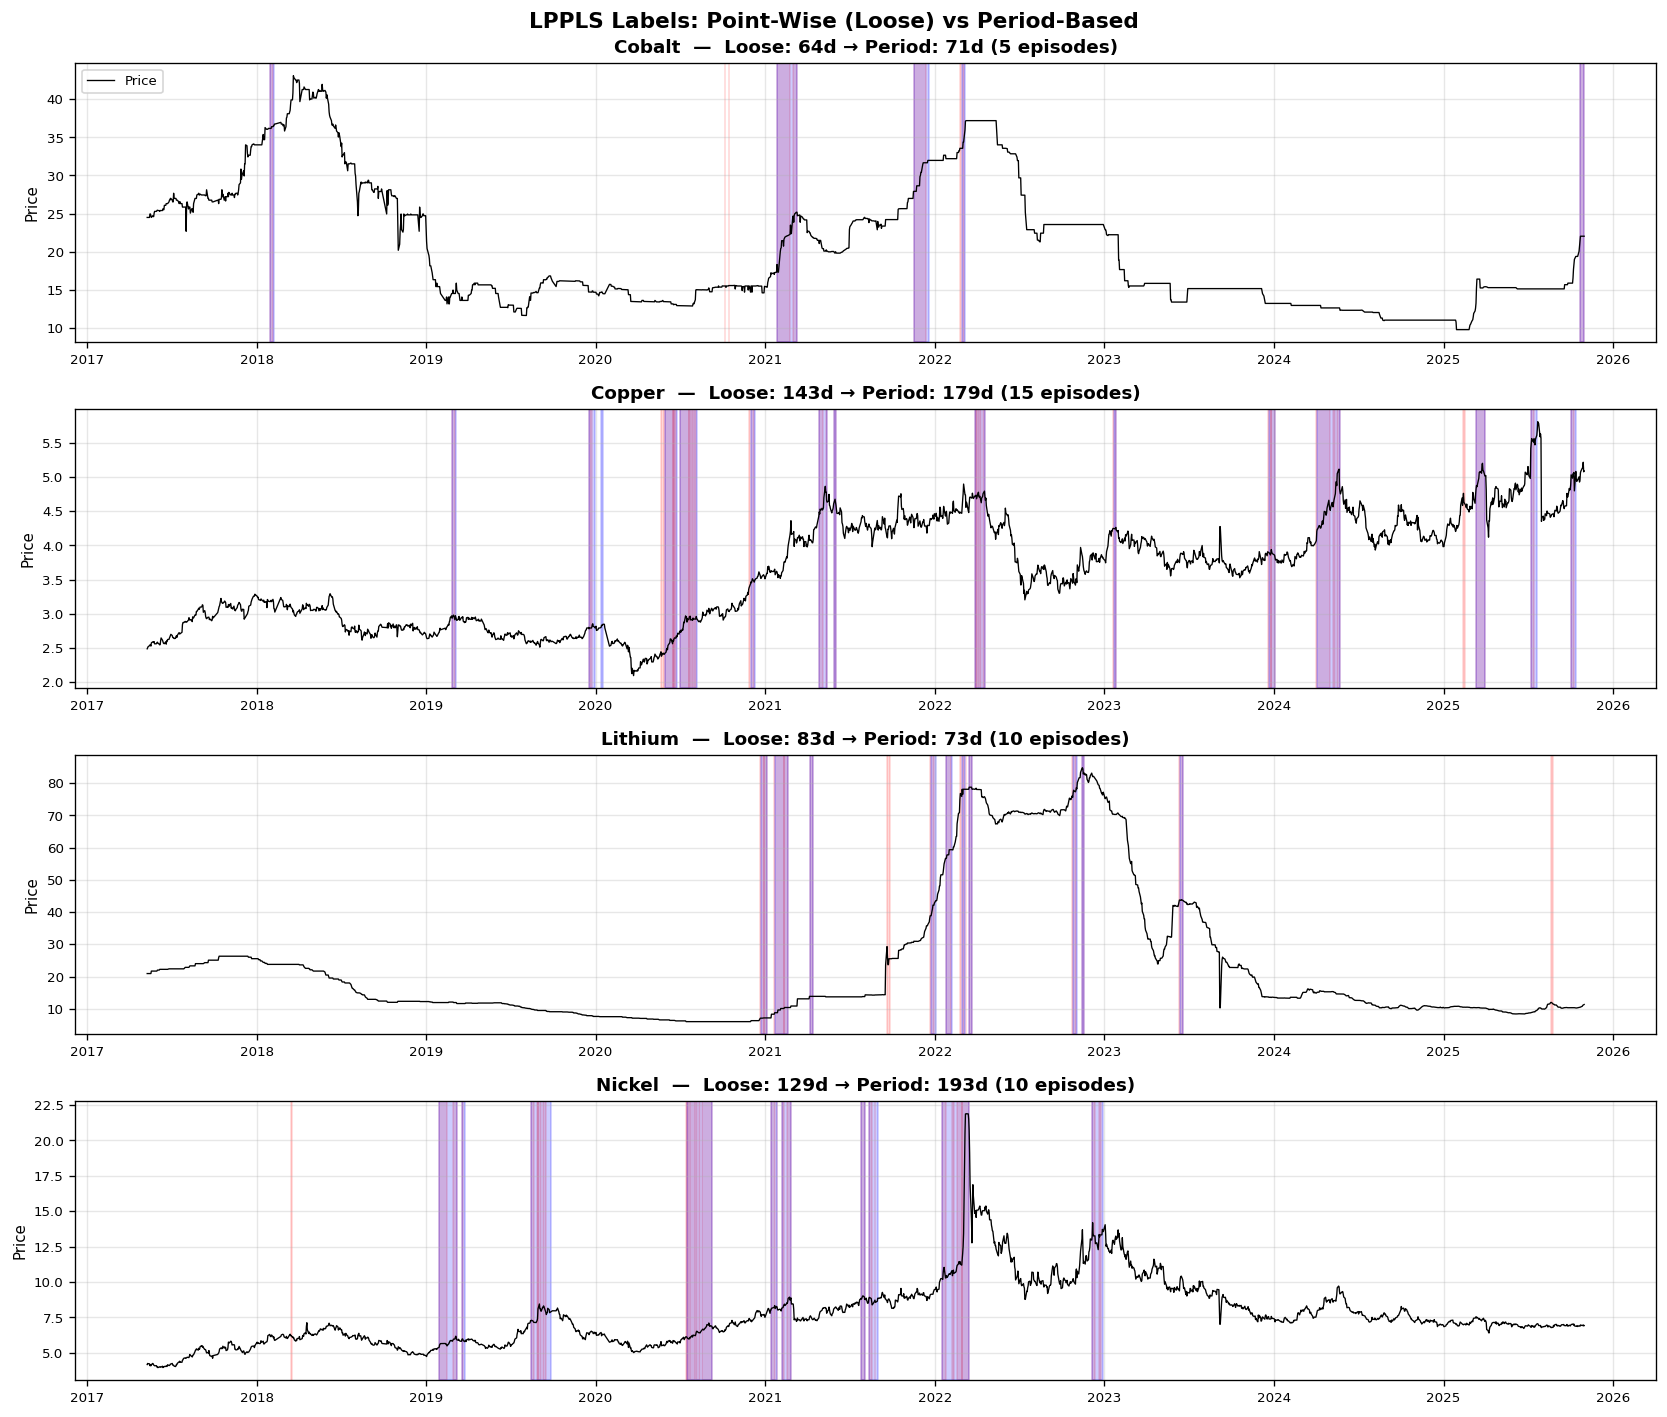

Saved -> outputs/lppls_pointwise_vs_periods.png


In [13]:
# ── Diagnostic plot: point-wise (loose) vs period-based labels ────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for idx, (metal, col) in enumerate(metals.items()):
    ax = axes[idx]
    dates = df['Date']
    prices = df[col].values

    # Price line
    ax.plot(dates, prices, color='black', lw=0.8, label='Price')

    # Point-wise loose labels (light red)
    loose = lppls_bubbles_loose.get(metal, np.zeros(len(df)))
    in_b = False
    for i in range(len(loose)):
        if loose[i] == 1 and not in_b:
            s = dates.iloc[i]; in_b = True
        elif (loose[i] == 0 or i == len(loose) - 1) and in_b:
            ax.axvspan(s, dates.iloc[i], color='red', alpha=0.15, label='Loose (point-wise)' if i < 50 else '')
            in_b = False

    # Period-based labels (blue)
    period = lppls_bubbles_periods.get(metal, np.zeros(len(df)))
    in_b = False
    for i in range(len(period)):
        if period[i] == 1 and not in_b:
            s = dates.iloc[i]; in_b = True
        elif (period[i] == 0 or i == len(period) - 1) and in_b:
            ax.axvspan(s, dates.iloc[i], color='blue', alpha=0.2, label='Period-based' if i < 50 else '')
            in_b = False

    n_loose = int(loose.sum())
    n_period = int(period.sum())
    d_p = np.diff(np.concatenate([[0], period, [0]]))
    n_ep = int((d_p == 1).sum())

    ax.set_title(f'{metal}  —  Loose: {n_loose}d → Period: {n_period}d ({n_ep} episodes)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Price', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

    # Legend (deduplicated)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    if idx == 0:
        ax.legend(by_label.values(), by_label.keys(), fontsize=8, loc='upper left')

plt.suptitle('LPPLS Labels: Point-Wise (Loose) vs Period-Based',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../outputs/lppls_pointwise_vs_periods.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> outputs/lppls_pointwise_vs_periods.png')